In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
from config import DATASETS_DIR
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D



In [ ]:
df = pd.read_csv(DATASETS_DIR / "cluster.csv", index_col=0)

In [94]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['well_id','time']).reset_index(drop=True)

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165552 entries, 0 to 165551
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   time               165552 non-null  datetime64[us]
 1   depth              165552 non-null  float64       
 2   angle              165552 non-null  float64       
 3   rotation           165552 non-null  float64       
 4   pressure_air       165552 non-null  int64         
 5   pressure_axis      165552 non-null  int64         
 6   pressure_rotation  165552 non-null  int64         
 7   well_id            165552 non-null  int64         
 8   d_depth            165552 non-null  float64       
 9   d_time             165552 non-null  float64       
 10  speed              165552 non-null  float64       
 11  n/p                165552 non-null  float64       
dtypes: datetime64[us](1), float64(7), int64(4)
memory usage: 15.2 MB


In [96]:
df

,time,depth,angle,rotation,pressure_air,pressure_axis,pressure_rotation,well_id,d_depth,d_time,speed,n/p
0,2025-10-07 22:18:08,4.6965,93.4,104.892,497,12781,13144,25512,0.1212,6.0,0.020200,0.008207
1,2025-10-07 22:18:13,4.8783,93.0,101.430,501,18971,18936,25512,0.1818,5.0,0.036360,0.005347
2,2025-10-07 22:18:18,5.0298,92.1,101.430,544,20153,18184,25512,0.1515,5.0,0.030300,0.005033
3,2025-10-07 22:18:23,5.1813,93.0,102.714,559,20162,17445,25512,0.1515,5.0,0.030300,0.005094
4,2025-10-07 22:18:50,5.3934,94.3,47.724,558,1233,10808,25512,0.2121,27.0,0.007856,0.038706
...,...,...,...,...,...,...,...,...,...,...,...,...
165547,2025-11-11 16:59:42,1.9998,92.4,81.072,404,8812,8670,31968,0.0303,5.0,0.006060,0.009200
165548,2025-11-11 16:59:47,2.0604,91.4,82.110,401,8793,8853,31968,0.0606,5.0,0.012120,0.009338
165549,2025-11-11 16:59:52,2.1210,88.4,82.044,400,8774,8974,31968,0.0606,5.0,0.012120,0.009351
165550,2025-11-11 16:59:57,2.1816,91.1,81.156,400,8703,10260,31968,0.0606,5.0,0.012120,0.009325


# functions

In [97]:
def show_pca_2d(X, labels):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab20', s=5, alpha=0.5)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()


In [98]:
def show_pca_3d(X, labels):
    pca_3d = PCA(n_components=3, random_state=42)
    X_pca_3d = pca_3d.fit_transform(X)

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], 
                        c=labels, cmap='tab20', s=5, alpha=0.5)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.show()

In [99]:
def show_umap_2d(X, labels):
    reducer = umap.UMAP(n_components=2)
    X_umap = reducer.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='tab20', s=5, alpha=0.5)
    plt.show()

In [100]:
def show_umap_3d(X, labels):
    reducer = umap.UMAP(n_components=3)
    X_umap_3d = reducer.fit_transform(X)

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_umap_3d[:,0], X_umap_3d[:,1], X_umap_3d[:,2], 
                        c=labels, cmap='tab20', s=5, alpha=0.5)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_zlabel("UMAP3")
    plt.show()

# baseline

In [102]:

features = ['pressure_axis','pressure_rotation','rotation','depth', 'angle']
X = df[features]
scaler = StandardScaler()
X = scaler.fit_transform(X)

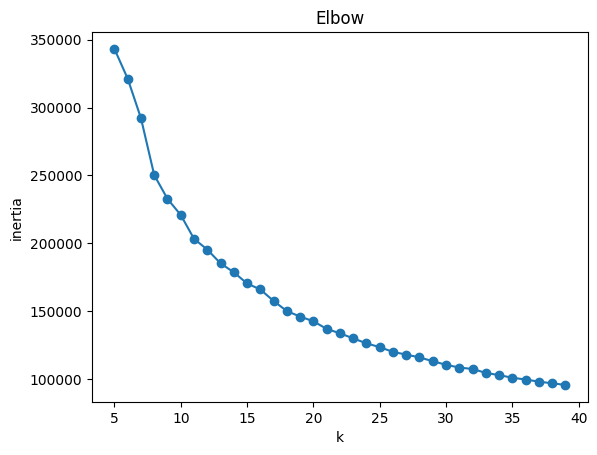

In [103]:
inertia = []
ks = range(5,40)
for k in ks:
    km = KMeans(n_clusters=k, random_state=21)
    km.fit(X) 
    inertia.append(km.inertia_)

plt.plot(ks, inertia, '-o')
plt.xlabel('k'); plt.ylabel('inertia'); plt.title('Elbow')
plt.show()

In [104]:
k = 17
km = KMeans(n_clusters=k, random_state=42)
labels = km.fit_predict(X)

In [105]:
df_clusters = df.copy()
df_clusters['cluster_baseline'] = labels

In [106]:
df_clusters

,time,depth,angle,rotation,pressure_air,pressure_axis,pressure_rotation,well_id,d_depth,d_time,speed,n/p,cluster_baseline
0,2025-10-07 22:18:08,4.6965,93.4,104.892,497,12781,13144,25512,0.1212,6.0,0.020200,0.008207,1
1,2025-10-07 22:18:13,4.8783,93.0,101.430,501,18971,18936,25512,0.1818,5.0,0.036360,0.005347,8
2,2025-10-07 22:18:18,5.0298,92.1,101.430,544,20153,18184,25512,0.1515,5.0,0.030300,0.005033,8
3,2025-10-07 22:18:23,5.1813,93.0,102.714,559,20162,17445,25512,0.1515,5.0,0.030300,0.005094,8
4,2025-10-07 22:18:50,5.3934,94.3,47.724,558,1233,10808,25512,0.2121,27.0,0.007856,0.038706,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
165547,2025-11-11 16:59:42,1.9998,92.4,81.072,404,8812,8670,31968,0.0303,5.0,0.006060,0.009200,4
165548,2025-11-11 16:59:47,2.0604,91.4,82.110,401,8793,8853,31968,0.0606,5.0,0.012120,0.009338,4
165549,2025-11-11 16:59:52,2.1210,88.4,82.044,400,8774,8974,31968,0.0606,5.0,0.012120,0.009351,4
165550,2025-11-11 16:59:57,2.1816,91.1,81.156,400,8703,10260,31968,0.0606,5.0,0.012120,0.009325,4


In [ ]:
df_clusters.to_csv(DATASETS_DIR / "regression.csv")

NameError: name 'df_clusters' is not defined

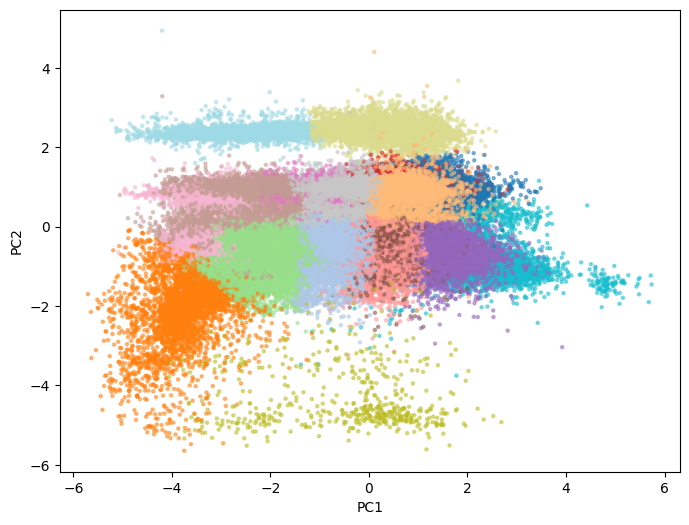

In [108]:
show_pca_2d(X, labels)

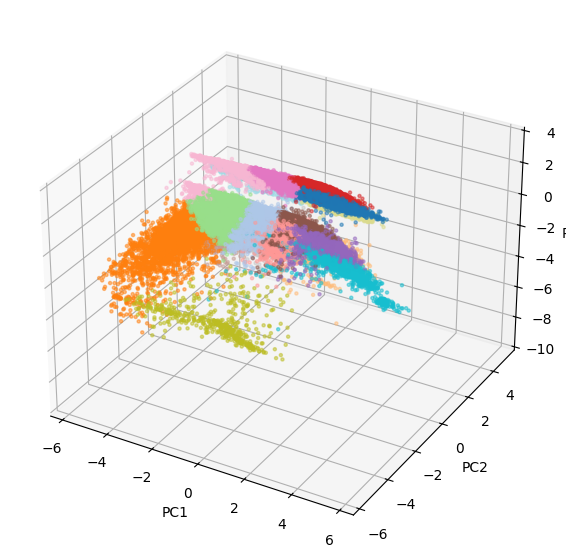

In [109]:
show_pca_3d(X, labels)

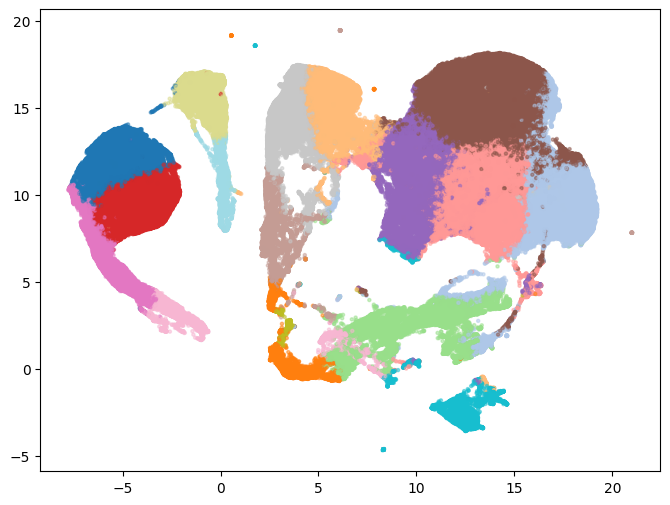

In [110]:
show_umap_2d(X, labels)

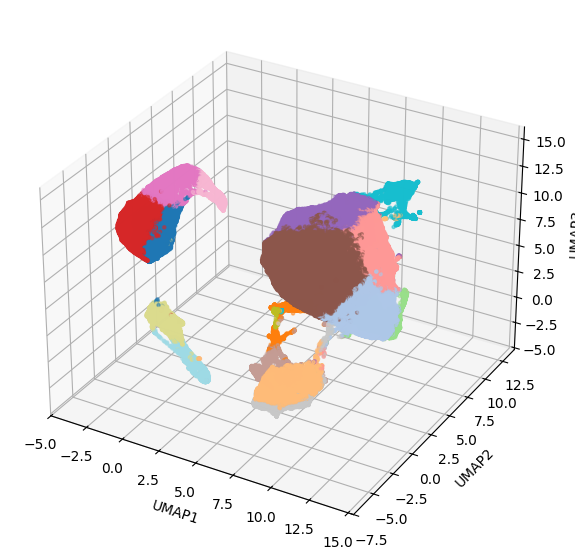

In [111]:
show_umap_3d(X, labels)

# tune